In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse
import os 
from scipy import stats

In [40]:
df = pd.read_csv('Wine.csv')

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
descriptor_cols = ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
                   'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins',
                   'Color_Intensity', 'Hue', 'OD280', 'Proline']

# Phương án 1: Loại bỏ outliers
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean


a = int(input("Chọn phương án xử lý outliers (1: Loại bỏ outliers, 2: Giữ nguyên outliers): "))
if a == 1:

    df_cleaned = remove_outliers_iqr(df, descriptor_cols)
else: 
    df_cleaned = df.copy()
    print("Giữ nguyên dữ liệu ban đầu.")

# Lấy dữ liệu đã xử lý
X = df_cleaned[descriptor_cols].values

# Chuẩn hóa (Z-score standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dữ liệu sau chuẩn hóa:")
print(f"Mean: {X_scaled.mean(axis=0)}")  # Gần 0
print(f"Std: {X_scaled.std(axis=0)}")    # Gần 1

In [44]:
# Chuyển thành DataFrame để dễ xem
df_scaled = pd.DataFrame(X_scaled, 
                         columns=descriptor_cols,
                         index=df_cleaned.index)

print("="*80)
print("DỮ LIỆU SAU CHUẨN HÓA (DataFrame)")
print("="*80)
print(df_scaled)

print("\n" + "="*80)
print("5 DÒNG ĐẦU TIÊN")
print("="*80)
print(df_scaled.head())

print("\n" + "="*80)
print("5 DÒNG CUỐI CÙNG")
print("="*80)
print(df_scaled.tail())

DỮ LIỆU SAU CHUẨN HÓA (DataFrame)
      Alcohol  Malic_Acid       Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    1.518613   -0.562250  0.232053     -1.169593   1.913905       0.808997   
1    0.246290   -0.499413 -0.827996     -2.490847   0.018145       0.568648   
2    0.196879    0.021231  1.109334     -0.268738   0.088358       0.808997   
3    1.691550   -0.346811  0.487926     -0.809251   0.930918       2.491446   
4    0.295700    0.227694  1.840403      0.451946   1.281985       0.808997   
..        ...         ...       ...           ...        ...            ...   
173  0.876275    2.974543  0.305159      0.301803  -0.332922      -0.985614   
174  0.493343    1.412609  0.414820      1.052516   0.158572      -0.793334   
175  0.332758    1.744744 -0.389355      0.151661   1.422412      -1.129824   
176  0.209232    0.227694  0.012732      0.151661   1.422412      -1.033684   
177  1.395086    1.583165  1.365208      1.502943  -0.262708      -0.392751   

     Flavanoids  

In [46]:
y_true = df['Customer_Segment']
print(y_true.value_counts())

Customer_Segment
2    71
1    59
3    48
Name: count, dtype: int64


In [ ]:
df_1 = df_scaled.copy()
df_2 = df_scaled[['Alcohol','Flavanoids', 'Total_Phenols', 'Color_Intensity', 'OD280', 'Proline']].copy()
df_1.head()

In [27]:
df_2.head()

,Alcohol,Flavanoids,Total_Phenols,Color_Intensity,OD280,Proline
0,1.515163,1.055948,0.828643,0.282097,1.828097,0.982174
1,0.209648,0.749315,0.589411,-0.304357,1.096928,0.934830
2,0.158948,1.239928,0.828643,0.300715,0.773526,1.360929
3,1.692612,1.495455,2.503264,1.287448,1.167233,2.292034
4,0.260347,0.677767,0.828643,-0.332284,0.436064,-0.059401


✓ df_1 shape: (161, 13) (tất cả features)
✓ df_2 shape: (161, 6) (6 features chọn lọc)

✓ Số mẫu (N): 161
✓ Số chiều (p): 6
✓ Số cụm (K): 3

BƯỚC 2: KHỞI TẠO THAM SỐ NGẪU NHIÊN

✓ P_k (xác suất tiên nghiệm):
[0.33333333 0.33333333 0.33333333]

✓ μ_k (trung bình các cụm):
[[-2.05916095 -0.01726795  0.31828206 -0.90942989 -0.43571444 -1.00944401]
 [-0.77899517  0.06450087 -0.4472591  -1.38417901  0.4782466  -1.29035374]
 [ 1.02084188 -1.22335804 -0.76623459  1.85063116 -1.37779736 -0.86425471]]

✓ Σ_k đã được khởi tạo (shape: 6x6 cho mỗi cụm)

BƯỚC 3: XÂY DỰNG HÀM F_MIX(x)

✓ Hàm F_mix đã được định nghĩa
✓ Ví dụ: F_mix(x[0]) = 0.000000

BƯỚC 4: XÂY DỰNG HÀM LOG-LIKELIHOOD

✓ Log-likelihood ban đầu: -1587.4731

BƯỚC 5: THUẬT TOÁN EXPECTATION-MAXIMIZATION (EM)

Bắt đầu thuật toán EM...
  Iteration 1: Log-likelihood = -923.5590
  Iteration 11: Log-likelihood = -793.6115
  Iteration 21: Log-likelihood = -785.1394

✓ Hội tụ tại iteration 25

BƯỚC 6: GÁN NHÃN CHO CÁC ĐIỂM DỮ LIỆU

✓ Số điểm tr

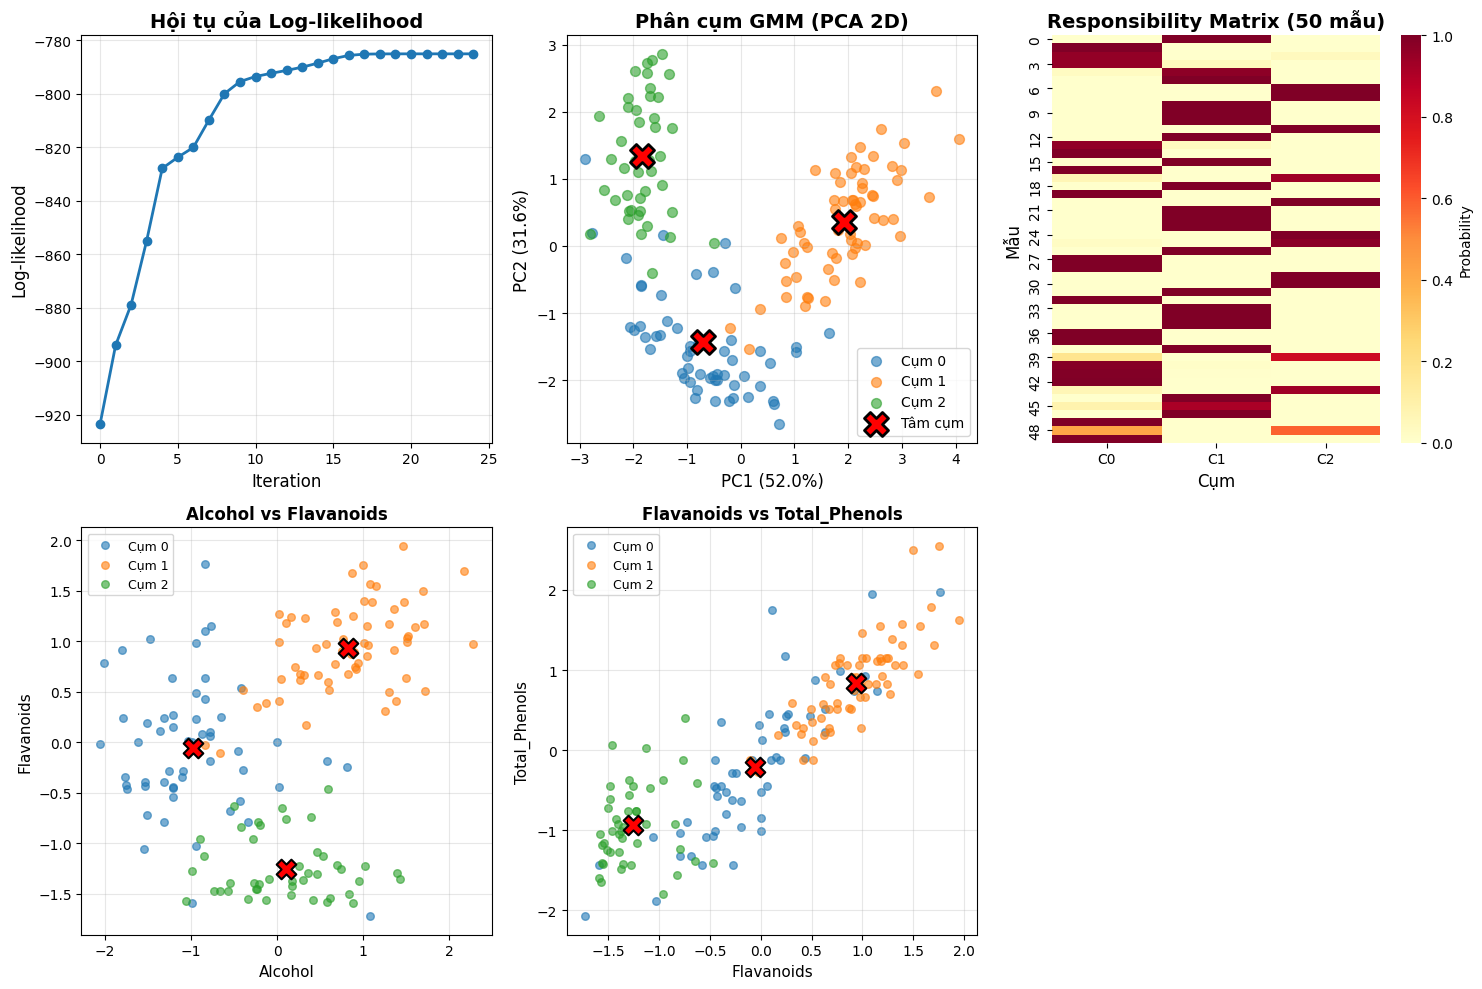


✅ HOÀN THÀNH PHÂN CỤM GMM VỚI THUẬT TOÁN EM

📌 Kết quả:
  - Số cụm: 3
  - Log-likelihood cuối: -785.1371
  - Số iterations: 25
  - Phân bố cụm: [np.int64(55), np.int64(62), np.int64(44)]

💾 Cluster labels đã được lưu trong biến: cluster_labels


In [ ]:
print(f"✓ df_1 shape: {df_1.shape} (tất cả features)")
print(f"✓ df_2 shape: {df_2.shape} (6 features chọn lọc)")

# Chọn data để phân cụm 
X = df_2.values
N, p = X.shape
K = 3  # Số cụm (có thể thay đổi)

print(f"\n✓ Số mẫu (N): {N}")
print(f"✓ Số chiều (p): {p}")
print(f"✓ Số cụm (K): {K}")

# BƯỚC 2: KHỞI TẠO THAM SỐ


np.random.seed(42)

# P_k: Xác suất tiên nghiệm (prior probabilities)
# Khởi tạo đồng đều cho các cụm
P = np.ones(K) / K
print(f"\n✓ P_k (xác suất tiên nghiệm):\n{P}")

# mu_k: Trung bình của mỗi cụm (mean vectors)
# Khởi tạo ngẫu nhiên từ dữ liệu
random_idx = np.random.choice(N, K, replace=False)
mu = X[random_idx]
print(f"\n✓ μ_k (trung bình các cụm):\n{mu}")

# Sigma_k: Ma trận hiệp phương sai của mỗi cụm (covariance matrices)
# Khởi tạo là ma trận đơn vị nhân với phương sai mẫu
sigma = [np.eye(p) * np.var(X) for _ in range(K)]
print(f"\n✓ Σ_k đã được khởi tạo (shape: {p}x{p} cho mỗi cụm)")

# ============================================================
# BƯỚC 3: XÂY DỰNG HÀM F_MIX(x) - MẬT ĐỘ HỖN HỢP
# ============================================================
print("\n" + "=" * 70)
print("BƯỚC 3: XÂY DỰNG HÀM F_MIX(x)")
print("=" * 70)

def gaussian_pdf(x, mu, sigma):
    """
    Hàm mật độ xác suất Gaussian đa biến
    f_k(x) = (2π)^(-p/2) |Σ_k|^(-1/2) exp[-1/2 (x-μ_k)'Σ_k^(-1)(x-μ_k)]
    """
    return multivariate_normal.pdf(x, mean=mu, cov=sigma, allow_singular=True)

def f_mix(x, P, mu, sigma, K):
    """
    Hàm mật độ hỗn hợp (Mixture density function)
    F_mix(x) = Σ P_k * f_k(x) với k=1..K
    """
    density = 0
    for k in range(K):
        density += P[k] * gaussian_pdf(x, mu[k], sigma[k])
    return density

# Kiểm tra hàm f_mix với một mẫu
sample_density = f_mix(X[0], P, mu, sigma, K)
print(f"\n✓ Hàm F_mix đã được định nghĩa")
print(f"✓ Ví dụ: F_mix(x[0]) = {sample_density:.6f}")


# BƯỚC 4: XÂY DỰNG HÀM LOG-LIKELIHOOD



def log_likelihood(X, P, mu, sigma, K):
    """
    Hàm log-likelihood:
    log L = Σ log[F_mix(x_j)] với j=1..N
    """
    N = X.shape[0]
    log_L = 0
    
    for j in range(N):
        mix_density = f_mix(X[j], P, mu, sigma, K)
        # Tránh log(0)
        if mix_density > 1e-10:
            log_L += np.log(mix_density)
        else:
            log_L += -10  # Giá trị rất nhỏ
    
    return log_L

initial_log_L = log_likelihood(X, P, mu, sigma, K)
print(f"\n✓ Log-likelihood ban đầu: {initial_log_L:.4f}")




# BƯỚC 5: THUẬT TOÁN EM


def em_algorithm(X, K, max_iter=100, tol=1e-4, verbose=True):
    """
    Thuật toán EM để tối ưu GMM
    
    E-step: Tính xác suất hậu nghiệm (responsibility)
            γ_jk = P(cụm k | x_j)
    
    M-step: Cập nhật tham số P_k, μ_k, Σ_k
    """
    N, p = X.shape
    
    # Khởi tạo tham số
    np.random.seed(42)
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    
    log_L_history = []
    
    for iteration in range(max_iter):
        # ========== E-STEP ==========
        # Tính responsibility: γ_jk = P_k * f_k(x_j) / F_mix(x_j)
        gamma = np.zeros((N, K))
        
        for j in range(N):
            for k in range(K):
                numerator = P[k] * gaussian_pdf(X[j], mu[k], sigma[k])
                denominator = f_mix(X[j], P, mu, sigma, K)
                
                if denominator > 1e-10:
                    gamma[j, k] = numerator / denominator
                else:
                    gamma[j, k] = 1 / K  # Phân bố đều nếu mẫu số = 0
        
        # Chuẩn hóa gamma để tổng theo k = 1
        gamma = gamma / gamma.sum(axis=1, keepdims=True)
        
        # ========== M-STEP ==========
        N_k = gamma.sum(axis=0)  # Số lượng hiệu dụng trong mỗi cụm
        
        # Cập nhật P_k
        P = N_k / N
        
        # Cập nhật μ_k
        for k in range(K):
            mu[k] = np.sum(gamma[:, k].reshape(-1, 1) * X, axis=0) / N_k[k]
        
        # Cập nhật Σ_k
        for k in range(K):
            diff = X - mu[k]
            weighted_diff = gamma[:, k].reshape(-1, 1) * diff
            sigma[k] = (weighted_diff.T @ diff) / N_k[k]
            
            # Thêm regularization để tránh singular matrix
            sigma[k] += np.eye(p) * 1e-6
        
        # Tính log-likelihood
        log_L = log_likelihood(X, P, mu, sigma, K)
        log_L_history.append(log_L)
        
        if verbose and (iteration % 10 == 0 or iteration == max_iter - 1):
            print(f"  Iteration {iteration + 1}: Log-likelihood = {log_L:.4f}")
        
        # Kiểm tra hội tụ
        if iteration > 0 and abs(log_L_history[-1] - log_L_history[-2]) < tol:
            print(f"\n✓ Hội tụ tại iteration {iteration + 1}")
            break
    
    return P, mu, sigma, gamma, log_L_history

# Chạy thuật toán EM
print("\nBắt đầu thuật toán EM...")
P_final, mu_final, sigma_final, gamma_final, log_L_history = em_algorithm(
    X, K, max_iter=100, tol=1e-4, verbose=True
)



# BƯỚC 6: GÁN NHÃN CHO CÁC ĐIỂM DỮ LIỆU

# Gán mỗi điểm vào cụm có xác suất cao nhất
cluster_labels = np.argmax(gamma_final, axis=1)

print(f"\n✓ Số điểm trong mỗi cụm:")
for k in range(K):
    count = np.sum(cluster_labels == k)
    print(f"  Cụm {k}: {count} điểm ({count/N*100:.1f}%)")





# BƯỚC 7: KẾT QUẢ VÀ TRỰC QUAN HÓA

print("\n" + "=" * 70)
print("BƯỚC 7: KẾT QUẢ VÀ TRỰC QUAN HÓA")
print("=" * 70)

print("\n📊 THAM SỐ CUỐI CÙNG:")
print(f"\nP_k (Xác suất cụm):\n{P_final}")
print(f"\nμ_k (Trung bình cụm):")
for k in range(K):
    print(f"  Cụm {k}: {mu_final[k]}")

# Vẽ biểu đồ log-likelihood
plt.figure(figsize=(15, 10))

# Plot 1: Log-likelihood convergence
plt.subplot(2, 3, 1)
plt.plot(log_L_history, marker='o', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Log-likelihood', fontsize=12)
plt.title('Hội tụ của Log-likelihood', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Phân bố các cụm với PCA (2D)
plt.subplot(2, 3, 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

for k in range(K):
    mask = cluster_labels == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Cụm {k}', alpha=0.6, s=50)

# Vẽ tâm các cụm
mu_pca = pca.transform(mu_final)
plt.scatter(mu_pca[:, 0], mu_pca[:, 1], 
           c='red', marker='X', s=300, 
           edgecolors='black', linewidth=2,
           label='Tâm cụm', zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Phân cụm GMM (PCA 2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap của responsibility matrix
plt.subplot(2, 3, 3)
# Chọn 50 mẫu ngẫu nhiên để hiển thị
sample_idx = np.random.choice(N, min(50, N), replace=False)
sns.heatmap(gamma_final[sample_idx], cmap='YlOrRd', 
           xticklabels=[f'C{k}' for k in range(K)],
           cbar_kws={'label': 'Probability'})
plt.ylabel('Mẫu', fontsize=12)
plt.xlabel('Cụm', fontsize=12)
plt.title('Responsibility Matrix (50 mẫu)', fontsize=14, fontweight='bold')

# Plot 4-6: Phân phối từng cặp features
feature_names = df_2.columns
plot_idx = 4
for i in range(2):
    for j in range(i+1, min(i+2, p)):
        if plot_idx > 6:
            break
        plt.subplot(2, 3, plot_idx)
        
        for k in range(K):
            mask = cluster_labels == k
            plt.scatter(X[mask, i], X[mask, j], 
                       label=f'Cụm {k}', alpha=0.6, s=30)
        
        # Vẽ tâm
        plt.scatter(mu_final[:, i], mu_final[:, j],
                   c='red', marker='X', s=200,
                   edgecolors='black', linewidth=1.5,
                   zorder=5)
        
        plt.xlabel(feature_names[i], fontsize=11)
        plt.ylabel(feature_names[j], fontsize=11)
        plt.title(f'{feature_names[i]} vs {feature_names[j]}', 
                 fontsize=12, fontweight='bold')
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
        plot_idx += 1

plt.tight_layout()
plt.show()

# ============================================================
# KẾT LUẬN
# ============================================================
print("\n" + "=" * 70)
print("✅ HOÀN THÀNH PHÂN CỤM GMM VỚI THUẬT TOÁN EM")
print("=" * 70)
print(f"\n📌 Kết quả:")
print(f"  - Số cụm: {K}")
print(f"  - Log-likelihood cuối: {log_L_history[-1]:.4f}")
print(f"  - Số iterations: {len(log_L_history)}")
print(f"  - Phân bố cụm: {[np.sum(cluster_labels == k) for k in range(K)]}")



CELL 1: TỐI ƯU MÔ HÌNH GMM BẰNG BIC CRITERION

📊 Dữ liệu: N=161 mẫu, p=6 chiều
Features: ['Alcohol', 'Flavanoids', 'Total_Phenols', 'Color_Intensity', 'OD280', 'Proline']

CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI

SPHERICAL_EQUAL:
  • Σ_k = η²I (Spherical, Equal)
  • Tất cả cụm có cùng phương sai, hình cầu
  • Số tham số: K(p + 1)

SPHERICAL_VARYING:
  • Σ_k = η_k²I (Spherical, Varying)
  • Mỗi cụm có phương sai khác nhau, hình cầu
  • Số tham số: K(p + 2) - 1

DIAGONAL:
  • Σ_k = η_k²Diag(λ₁,...,λₚ) (Diagonal)
  • Ma trận chéo với scale khác nhau
  • Số tham số: K(p + 2) + p - 1

FULL:
  • Σ_k = Full (Unrestricted)
  • Ma trận hiệp phương sai đầy đủ
  • Số tham số: (K-1) + K×p + K×p(p+1)/2

GRID SEARCH: TỐI ƯU HÓA MÔ HÌNH

Đang chạy Grid Search...
• Số cụm K: [2, 3, 4, 5, 6]
• Cấu trúc covariance: 4 loại
• Tổng số mô hình: 20
  ✓ K=2, spherical_equal     : BIC=-2562.17, LogL=-1209.95, Params=14
  ✓ K=2, spherical_varying   : BIC=-2504.69, LogL=-1176.12, Params=15
  ✓ K=2, diagonal        

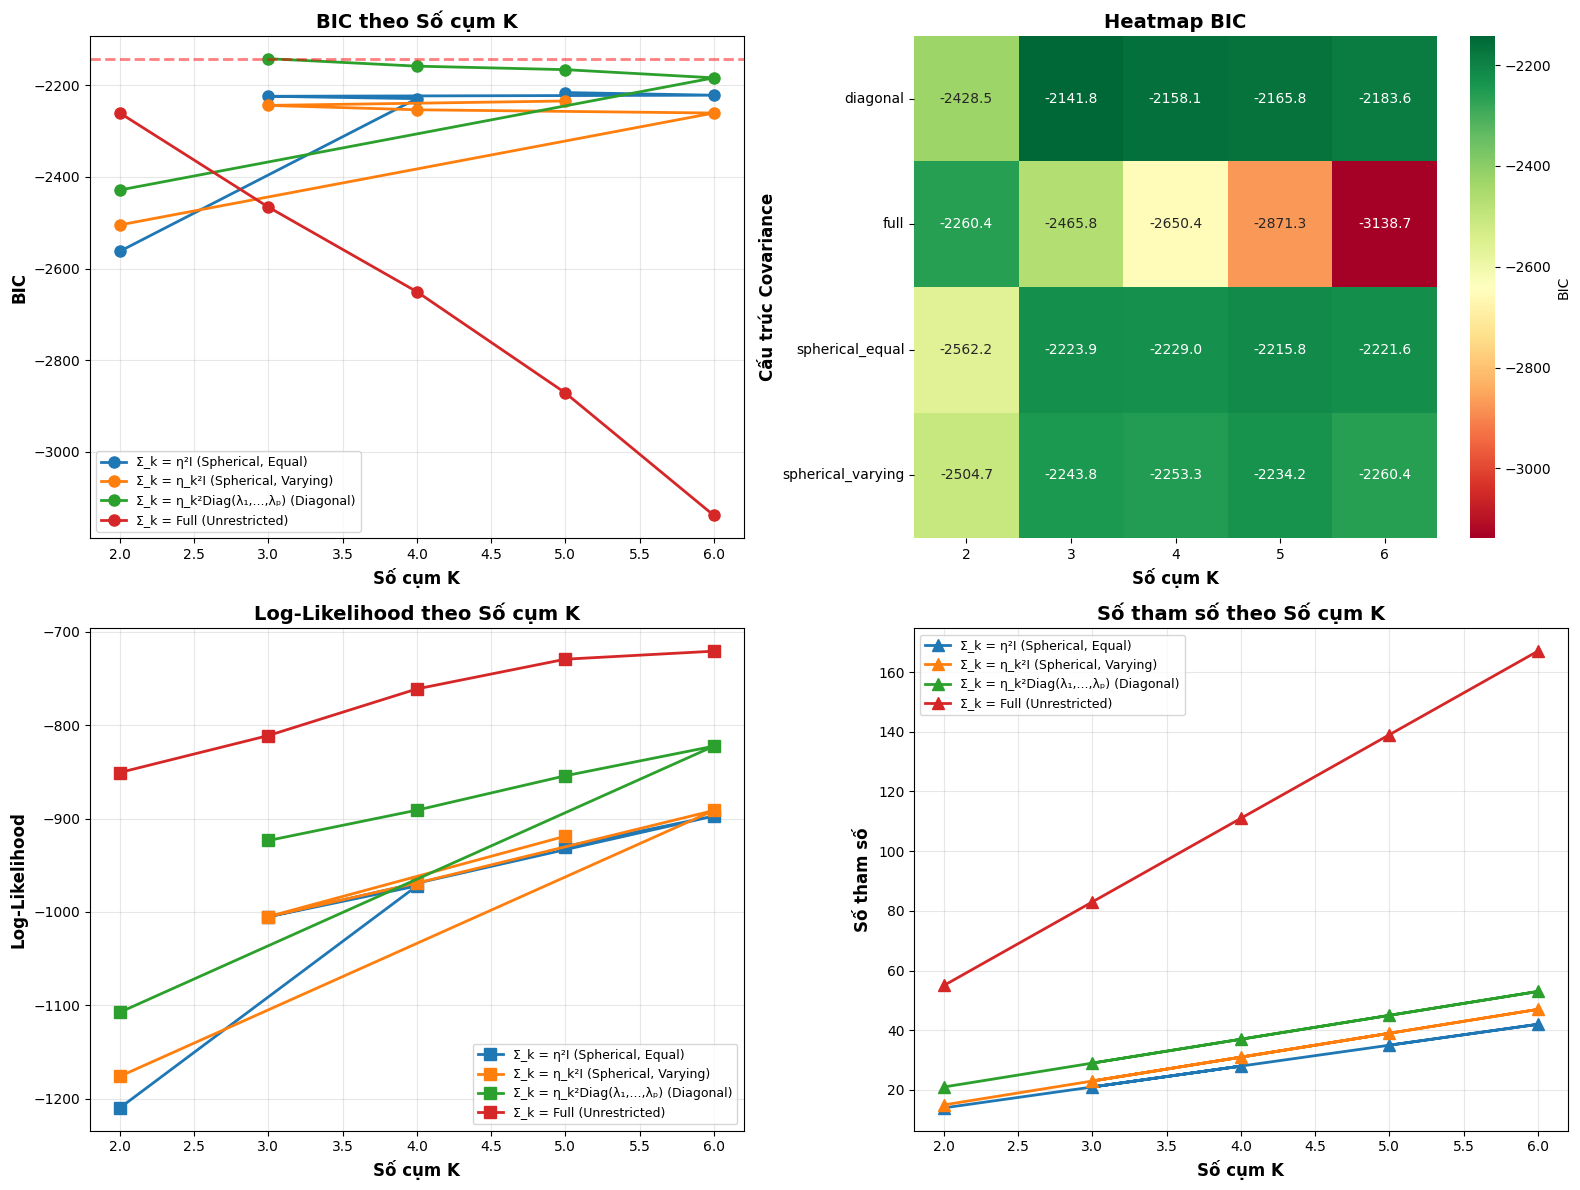


✅ HOÀN THÀNH CELL 1

💾 Các biến đã được lưu:
  • optimal_K = 3
  • optimal_cov_type = 'diagonal'
  • optimal_P, optimal_mu, optimal_sigma, optimal_gamma
  • results_df (DataFrame chứa tất cả kết quả)

➡️  Sẵn sàng chạy CELL 2 để áp dụng mô hình tối ưu!


In [ ]:
"""
TỐI ƯU SỐ CỤM K VÀ CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI
"""
print("=" * 80)
print("CELL 1: TỐI ƯU MÔ HÌNH GMM BẰNG BIC CRITERION")
print("=" * 80)

# Dữ liệu từ cell trước
X = df_2.values
N, p = X.shape

print(f"\n📊 Dữ liệu: N={N} mẫu, p={p} chiều")
print(f"Features: {list(df_2.columns)}")
# ============================================================
print("\n" + "=" * 80)
print("CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI")
print("=" * 80)

covariance_structures = {
    'spherical_equal': {
        'name': 'Σ_k = η²I (Spherical, Equal)',
        'description': 'Tất cả cụm có cùng phương sai, hình cầu',
        'n_params_formula': 'K(p + 1)'
    },
    'spherical_varying': {
        'name': 'Σ_k = η_k²I (Spherical, Varying)',
        'description': 'Mỗi cụm có phương sai khác nhau, hình cầu',
        'n_params_formula': 'K(p + 2) - 1'
    },
    'diagonal': {
        'name': 'Σ_k = η_k²Diag(λ₁,...,λₚ) (Diagonal)',
        'description': 'Ma trận chéo với scale khác nhau',
        'n_params_formula': 'K(p + 2) + p - 1'
    },
    'full': {
        'name': 'Σ_k = Full (Unrestricted)',
        'description': 'Ma trận hiệp phương sai đầy đủ',
        'n_params_formula': '(K-1) + K×p + K×p(p+1)/2'
    }
}

for key, info in covariance_structures.items():
    print(f"\n{key.upper()}:")
    print(f"  • {info['name']}")
    print(f"  • {info['description']}")
    print(f"  • Số tham số: {info['n_params_formula']}")

# ============================================================
# HÀM TÍNH SỐ THAM SỐ
# ============================================================
def count_parameters(K, p, cov_type):
    """
    Tính số tham số theo công thức từ giáo trình (phần 12.5)
    
    Theo giáo trình:
    - P_k: K-1 tham số (vì tổng = 1)
    - μ_k: K × p tham số
    - Σ_k: phụ thuộc vào cấu trúc
    """
    if cov_type == 'spherical_equal':
        # Σ_k = η²I: 1 tham số cho variance chung
        return K * (p + 1)
    
    elif cov_type == 'spherical_varying':
        # Σ_k = η_k²I: K tham số cho K variances
        return K * (p + 2) - 1
    
    elif cov_type == 'diagonal':
        # Σ_k = η_k²Diag(): K scales + p diagonal elements
        return K * (p + 2) + p - 1
    
    elif cov_type == 'full':
        # Ma trận đầy đủ: K × p(p+1)/2
        return (K - 1) + K * p + K * p * (p + 1) // 2
    
    return 0

# ============================================================
# HÀM TÍNH BIC
# ============================================================
def compute_BIC(log_likelihood, N, n_params):
    """
    BIC = 2*ln(L_max) - 2*ln(N) × (số tham số)
    
    Theo công thức (12-20) trong giáo trình
    """
    return 2 * log_likelihood - 2 * np.log(N) * n_params

# ============================================================
# THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE
# ============================================================
def em_with_cov_structure(X, K, cov_type='full', max_iter=100, tol=1e-4):
    """
    EM algorithm với ràng buộc cấu trúc covariance
    """
    N, p = X.shape
    np.random.seed(42)
    
    # Khởi tạo
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    # Khởi tạo covariance theo cấu trúc
    if cov_type == 'spherical_equal':
        variance = np.var(X)
        sigma = [np.eye(p) * variance for _ in range(K)]
    elif cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else:  # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    for iteration in range(max_iter):
        # E-step
        gamma = np.zeros((N, K))
        for j in range(N):
            for k in range(K):
                try:
                    gamma[j, k] = P[k] * multivariate_normal.pdf(
                        X[j], mean=mu[k], cov=sigma[k], allow_singular=True
                    )
                except:
                    gamma[j, k] = 1e-10
        
        # Normalize
        gamma_sum = gamma.sum(axis=1, keepdims=True)
        gamma = gamma / (gamma_sum + 1e-10)
        
        # M-step
        N_k = gamma.sum(axis=0) + 1e-10
        P = N_k / N
        
        # Update mu
        for k in range(K):
            mu[k] = np.sum(gamma[:, k].reshape(-1, 1) * X, axis=0) / N_k[k]
        
        # Update sigma với ràng buộc cấu trúc
        if cov_type == 'spherical_equal':
            # Σ_k = η²I: tính variance chung cho tất cả cụm
            total_variance = 0
            for k in range(K):
                diff = X - mu[k]
                total_variance += np.sum(gamma[:, k].reshape(-1, 1) * (diff ** 2))
            variance = total_variance / (N * p)
            sigma = [np.eye(p) * variance for _ in range(K)]
            
        elif cov_type == 'spherical_varying':
            # Σ_k = η_k²I: mỗi cụm có variance riêng
            for k in range(K):
                diff = X - mu[k]
                variance_k = np.sum(gamma[:, k].reshape(-1, 1) * (diff ** 2)) / (N_k[k] * p)
                sigma[k] = np.eye(p) * variance_k
                
        elif cov_type == 'diagonal':
            # Ma trận chéo
            for k in range(K):
                diff = X - mu[k]
                weighted_var = np.sum(gamma[:, k].reshape(-1, 1) * (diff ** 2), axis=0) / N_k[k]
                sigma[k] = np.diag(weighted_var + 1e-6)
                
        else:  # full
            for k in range(K):
                diff = X - mu[k]
                weighted_diff = gamma[:, k].reshape(-1, 1) * diff
                sigma[k] = (weighted_diff.T @ diff) / N_k[k] + np.eye(p) * 1e-6
        
        # Tính log-likelihood
        log_L = 0
        for j in range(N):
            mix_density = sum(P[k] * multivariate_normal.pdf(
                X[j], mean=mu[k], cov=sigma[k], allow_singular=True
            ) for k in range(K))
            log_L += np.log(mix_density + 1e-10)
        
        # Kiểm tra hội tụ
        if iteration > 0 and abs(log_L - prev_log_L) < tol:
            break
        prev_log_L = log_L
    
    return P, mu, sigma, gamma, log_L

# ============================================================
# GRID SEARCH: TỔNG HỢP TẤT CẢ MÔ HÌNH
# ============================================================
print("\n" + "=" * 80)
print("GRID SEARCH: TỐI ƯU HÓA MÔ HÌNH")
print("=" * 80)

K_range = range(2, 7)  # Test K = 2, 3, 4, 5, 6
cov_types = ['spherical_equal', 'spherical_varying', 'diagonal', 'full']

results = []

print("\nĐang chạy Grid Search...")
print(f"• Số cụm K: {list(K_range)}")
print(f"• Cấu trúc covariance: {len(cov_types)} loại")
print(f"• Tổng số mô hình: {len(K_range) * len(cov_types)}")

for K in K_range:
    for cov_type in cov_types:
        # Chạy EM
        P, mu, sigma, gamma, log_L = em_with_cov_structure(
            X, K, cov_type=cov_type, max_iter=100, tol=1e-4
        )
        
        # Tính số tham số và BIC
        n_params = count_parameters(K, p, cov_type)
        bic = compute_BIC(log_L, N, n_params)
        
        results.append({
            'K': K,
            'Cov_Type': cov_type,
            'Cov_Name': covariance_structures[cov_type]['name'],
            'Log_Likelihood': log_L,
            'N_Params': n_params,
            'BIC': bic,
            'Model': (P, mu, sigma, gamma)
        })
        
        print(f"  ✓ K={K}, {cov_type:20s}: BIC={bic:8.2f}, LogL={log_L:8.2f}, Params={n_params}")

# Chuyển sang DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('BIC', ascending=False)

# ============================================================
# HIỂN THỊ KẾT QUẢ
# ============================================================
print("\n" + "=" * 80)
print("KẾT QUẢ TỐI ƯU HÓA")
print("=" * 80)

print("\n📊 TOP 10 MÔ HÌNH TỐT NHẤT (theo BIC):")
print(results_df[['K', 'Cov_Type', 'BIC', 'Log_Likelihood', 'N_Params']].head(10).to_string(index=False))

# Mô hình tối ưu
best_model = results_df.iloc[0]
print("\n" + "🏆" * 40)
print("MÔ HÌNH TỐI ƯU")
print("🏆" * 40)
print(f"\n✓ Số cụm K: {best_model['K']}")
print(f"✓ Cấu trúc Covariance: {best_model['Cov_Name']}")
print(f"✓ BIC: {best_model['BIC']:.4f}")
print(f"✓ Log-Likelihood: {best_model['Log_Likelihood']:.4f}")
print(f"✓ Số tham số: {best_model['N_Params']}")

# ============================================================
# TRỰC QUAN HÓA KẾT QUẢ
# ============================================================
print("\n" + "=" * 80)
print("TRỰC QUAN HÓA")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: BIC theo K cho từng cov_type
ax = axes[0, 0]
for cov_type in cov_types:
    subset = results_df[results_df['Cov_Type'] == cov_type]
    ax.plot(subset['K'], subset['BIC'], marker='o', linewidth=2, 
            label=covariance_structures[cov_type]['name'], markersize=8)
ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
ax.set_ylabel('BIC', fontsize=12, fontweight='bold')
ax.set_title('BIC theo Số cụm K', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=best_model['BIC'], color='red', linestyle='--', linewidth=2, alpha=0.5)

# Plot 2: Heatmap BIC
ax = axes[0, 1]
pivot_bic = results_df.pivot(index='Cov_Type', columns='K', values='BIC')
sns.heatmap(pivot_bic, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, 
            cbar_kws={'label': 'BIC'})
ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
ax.set_ylabel('Cấu trúc Covariance', fontsize=12, fontweight='bold')
ax.set_title('Heatmap BIC', fontsize=14, fontweight='bold')

# Plot 3: Log-Likelihood theo K
ax = axes[1, 0]
for cov_type in cov_types:
    subset = results_df[results_df['Cov_Type'] == cov_type]
    ax.plot(subset['K'], subset['Log_Likelihood'], marker='s', linewidth=2,
            label=covariance_structures[cov_type]['name'], markersize=8)
ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
ax.set_ylabel('Log-Likelihood', fontsize=12, fontweight='bold')
ax.set_title('Log-Likelihood theo Số cụm K', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Số tham số theo K
ax = axes[1, 1]
for cov_type in cov_types:
    subset = results_df[results_df['Cov_Type'] == cov_type]
    ax.plot(subset['K'], subset['N_Params'], marker='^', linewidth=2,
            label=covariance_structures[cov_type]['name'], markersize=8)
ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
ax.set_ylabel('Số tham số', fontsize=12, fontweight='bold')
ax.set_title('Số tham số theo Số cụm K', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gmm_model_selection.png', dpi=300, bbox_inches='tight')
print("\n✓ Đã lưu biểu đồ: gmm_model_selection.png")
plt.show()

# Lưu mô hình tối ưu để dùng cho cell tiếp theo
optimal_K = int(best_model['K'])
optimal_cov_type = best_model['Cov_Type']
optimal_P, optimal_mu, optimal_sigma, optimal_gamma = best_model['Model']

print("\n" + "=" * 80)
print("✅ HOÀN THÀNH CELL 1")
print("=" * 80)
print(f"\n💾 Các biến đã được lưu:")
print(f"  • optimal_K = {optimal_K}")
print(f"  • optimal_cov_type = '{optimal_cov_type}'")
print(f"  • optimal_P, optimal_mu, optimal_sigma, optimal_gamma")
print(f"  • results_df (DataFrame chứa tất cả kết quả)")



  • Số cụm K = 3
  • Cấu trúc Covariance = diagonal

PHÂN CỤM DỮ LIỆU VỚI MÔ HÌNH TỐI ƯU

📊 Phân bố các cụm:
  Cụm 0:  53 điểm ( 32.9%)
  Cụm 1:  60 điểm ( 37.3%)
  Cụm 2:  48 điểm ( 29.8%)

✓ Tổng: 161 điểm

THÔNG TIN CHI TIẾT CÁC CỤM

────────────────────────────────────────────────────────────────────────────────
CỤM 0 (53 điểm, 32.7%)
────────────────────────────────────────────────────────────────────────────────

📍 Trung bình (μ_0):
  • Alcohol             :  -1.0340
  • Flavanoids          :   0.0233
  • Total_Phenols       :  -0.1113
  • Color_Intensity     :  -0.9759
  • OD280               :   0.3449
  • Proline             :  -0.8321

📊 Ma trận Hiệp phương sai (Σ_0):
  • Diagonal elements:
    - Alcohol             : 0.335596
    - Flavanoids          : 0.268198
    - Total_Phenols       : 0.607359
    - Color_Intensity     : 0.124207
    - OD280               : 0.328592
    - Proline             : 0.176399

───────────────────────────────────────────────────────────────────

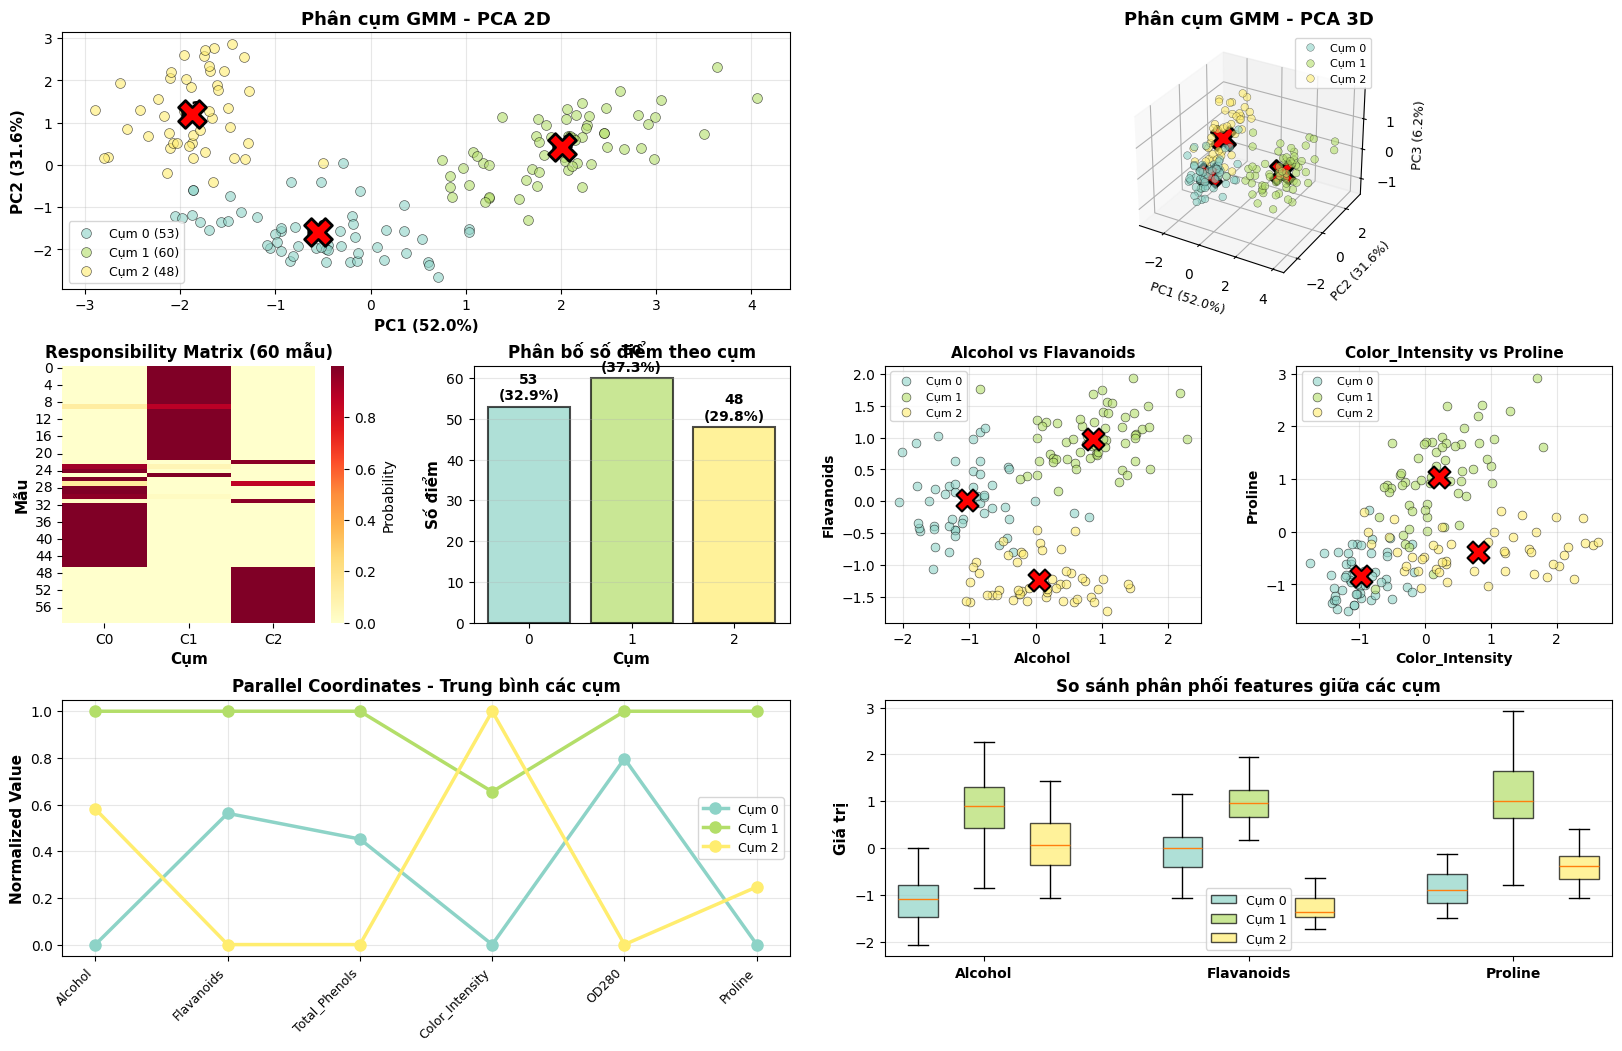


PHÂN TÍCH CHẤT LƯỢNG MÔ HÌNH

📊 Silhouette Score: 0.4418
   (Càng gần 1 càng tốt, > 0.5 là tốt)

📊 Entropy: 0.0256
   (Entropy thấp = phân cụm rõ ràng)

📊 Average Maximum Probability: 0.9912
   (Càng cao càng tốt, cho thấy độ tin cậy của phân cụm)

BẢNG TỔNG KẾT MÔ HÌNH TỐI ƯU

             Metric      Value
         Số cụm (K)          3
Cấu trúc Covariance   diagonal
                BIC -2141.8025
     Log-Likelihood  -923.5405
         Số tham số         29
   Silhouette Score     0.4418
            Entropy     0.0256
       Avg Max Prob     0.9912

LƯU KẾT QUẢ PHÂN CỤM

✓ Đã lưu kết quả: wine_clustering_results.csv

📋 Mẫu kết quả phân cụm (5 dòng đầu):
    Alcohol  Flavanoids  Total_Phenols  Color_Intensity     OD280   Proline  Cluster  Max_Probability   P_Cluster_0  P_Cluster_1   P_Cluster_2
0  1.515163    1.055948       0.828643         0.282097  1.828097  0.982174        1         1.000000  5.307167e-13     1.000000  4.634591e-31
1  0.209648    0.749315       0.589411        -0

In [30]:
"""
ÁP DỤNG MÔ HÌNH TỐI ƯU VÀ TRỰC QUAN HÓA CHI TIẾT
Sử dụng kết quả từ Cell trên

"""

print(f"  • Số cụm K = {optimal_K}")
print(f"  • Cấu trúc Covariance = {optimal_cov_type}")

# ============================================================
# GÁN NHÃN CHO CÁC ĐIỂM DỮ LIỆU
# ============================================================
print("\n" + "=" * 80)
print("PHÂN CỤM DỮ LIỆU VỚI MÔ HÌNH TỐI ƯU")
print("=" * 80)

# Gán mỗi điểm vào cụm có xác suất cao nhất
cluster_labels = np.argmax(optimal_gamma, axis=1)

# Thống kê phân bố cụm
print("\n📊 Phân bố các cụm:")
cluster_counts = []
for k in range(optimal_K):
    count = np.sum(cluster_labels == k)
    percentage = count / N * 100
    cluster_counts.append(count)
    print(f"  Cụm {k}: {count:3d} điểm ({percentage:5.1f}%)")

print(f"\n✓ Tổng: {N} điểm")

# ============================================================
# THÔNG TIN CHI TIẾT CỦA MỖI CỤM
# ============================================================
print("\n" + "=" * 80)
print("THÔNG TIN CHI TIẾT CÁC CỤM")
print("=" * 80)

feature_names = df_2.columns.tolist()

for k in range(optimal_K):
    print(f"\n{'─' * 80}")
    print(f"CỤM {k} ({cluster_counts[k]} điểm, {optimal_P[k]*100:.1f}%)")
    print(f"{'─' * 80}")
    
    print(f"\n📍 Trung bình (μ_{k}):")
    for i, fname in enumerate(feature_names):
        print(f"  • {fname:20s}: {optimal_mu[k][i]:8.4f}")
    
    print(f"\n📊 Ma trận Hiệp phương sai (Σ_{k}):")
    if optimal_cov_type == 'spherical_equal' or optimal_cov_type == 'spherical_varying':
        variance = optimal_sigma[k][0, 0]
        print(f"  • Variance (η²): {variance:.6f}")
        print(f"  • Structure: {variance:.6f} × I")
    elif optimal_cov_type == 'diagonal':
        print(f"  • Diagonal elements:")
        for i, fname in enumerate(feature_names):
            print(f"    - {fname:20s}: {optimal_sigma[k][i, i]:.6f}")
    else:  # full
        print(f"  • Full covariance matrix:")
        sigma_df = pd.DataFrame(optimal_sigma[k], 
                               index=feature_names, 
                               columns=feature_names)
        print(sigma_df.to_string())

# ============================================================
# THỐNG KÊ SO SÁNH GIỮA CÁC CỤM
# ============================================================
print("\n" + "=" * 80)
print("SO SÁNH GIỮA CÁC CỤM")
print("=" * 80)

# Tạo DataFrame với cluster labels
df_clustered = df_2.copy()
df_clustered['Cluster'] = cluster_labels

# Thống kê theo cụm
print("\n📈 Giá trị trung bình theo cụm:")
cluster_means = df_clustered.groupby('Cluster').mean()
print(cluster_means.to_string())

# ============================================================
# TRỰC QUAN HÓA TOÀN DIỆN
# ============================================================
print("\n" + "=" * 80)
print("TRỰC QUAN HÓA KẾT QUẢ")
print("=" * 80)

# Tạo color palette
colors = plt.cm.Set3(np.linspace(0, 1, optimal_K))

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# ============================================================
# Plot 1-2: PCA 2D và 3D
# ============================================================
# PCA 2D
ax1 = fig.add_subplot(gs[0, 0:2])
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

for k in range(optimal_K):
    mask = cluster_labels == k
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
               c=[colors[k]], label=f'Cụm {k} ({cluster_counts[k]})',
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Vẽ tâm cụm
mu_pca_2d = pca_2d.transform(optimal_mu)
for k in range(optimal_K):
    ax1.scatter(mu_pca_2d[k, 0], mu_pca_2d[k, 1],
               c='red', marker='X', s=400, edgecolors='black', 
               linewidth=2, zorder=5)
    ax1.annotate(f'μ{k}', (mu_pca_2d[k, 0], mu_pca_2d[k, 1]),
                fontsize=12, fontweight='bold', ha='center')

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax1.set_title('Phân cụm GMM - PCA 2D', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# PCA 3D
ax2 = fig.add_subplot(gs[0, 2:], projection='3d')
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

for k in range(optimal_K):
    mask = cluster_labels == k
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=[colors[k]], label=f'Cụm {k}',
               alpha=0.6, s=30, edgecolors='black', linewidth=0.3)

# Vẽ tâm 3D
mu_pca_3d = pca_3d.transform(optimal_mu)
for k in range(optimal_K):
    ax2.scatter(mu_pca_3d[k, 0], mu_pca_3d[k, 1], mu_pca_3d[k, 2],
               c='red', marker='X', s=300, edgecolors='black', linewidth=2)

ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=9)
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=9)
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=9)
ax2.set_title('Phân cụm GMM - PCA 3D', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)

# ============================================================
# Plot 3: Responsibility Matrix Heatmap
# ============================================================
ax3 = fig.add_subplot(gs[1, 0])
sample_size = min(60, N)
sample_idx = np.random.choice(N, sample_size, replace=False)
sample_idx = sorted(sample_idx)

sns.heatmap(optimal_gamma[sample_idx], cmap='YlOrRd', ax=ax3,
           xticklabels=[f'C{k}' for k in range(optimal_K)],
           cbar_kws={'label': 'Probability'})
ax3.set_ylabel('Mẫu', fontsize=11, fontweight='bold')
ax3.set_xlabel('Cụm', fontsize=11, fontweight='bold')
ax3.set_title(f'Responsibility Matrix ({sample_size} mẫu)', 
             fontsize=12, fontweight='bold')

# ============================================================
# Plot 4: Phân bố cụm
# ============================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(range(optimal_K), cluster_counts, color=colors, 
        edgecolor='black', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('Cụm', fontsize=11, fontweight='bold')
ax4.set_ylabel('Số điểm', fontsize=11, fontweight='bold')
ax4.set_title('Phân bố số điểm theo cụm', fontsize=12, fontweight='bold')
ax4.set_xticks(range(optimal_K))
for i, count in enumerate(cluster_counts):
    ax4.text(i, count + 1, f'{count}\n({count/N*100:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# ============================================================
# Plot 5-6: Scatter plots cho các cặp features quan trọng
# ============================================================
# Chọn 2 cặp features để visualize
important_pairs = [
    ('Alcohol', 'Flavanoids'),
    ('Color_Intensity', 'Proline')
]

for idx, (feat1, feat2) in enumerate(important_pairs):
    ax = fig.add_subplot(gs[1, 2+idx])
    
    feat1_idx = feature_names.index(feat1)
    feat2_idx = feature_names.index(feat2)
    
    for k in range(optimal_K):
        mask = cluster_labels == k
        ax.scatter(X[mask, feat1_idx], X[mask, feat2_idx],
                  c=[colors[k]], label=f'Cụm {k}',
                  alpha=0.6, s=40, edgecolors='black', linewidth=0.5)
    
    # Vẽ tâm
    for k in range(optimal_K):
        ax.scatter(optimal_mu[k, feat1_idx], optimal_mu[k, feat2_idx],
                  c='red', marker='X', s=250, edgecolors='black', 
                  linewidth=1.5, zorder=5)
    
    ax.set_xlabel(feat1, fontsize=10, fontweight='bold')
    ax.set_ylabel(feat2, fontsize=10, fontweight='bold')
    ax.set_title(f'{feat1} vs {feat2}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

# ============================================================
# Plot 7: Parallel Coordinates cho trung bình các cụm
# ============================================================
ax7 = fig.add_subplot(gs[2, :2])

# Chuẩn hóa để vẽ
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

for k in range(optimal_K):
    ax7.plot(range(len(feature_names)), cluster_means_norm.iloc[k],
            marker='o', linewidth=2.5, color=colors[k], 
            label=f'Cụm {k}', markersize=8)

ax7.set_xticks(range(len(feature_names)))
ax7.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
ax7.set_ylabel('Normalized Value', fontsize=11, fontweight='bold')
ax7.set_title('Parallel Coordinates - Trung bình các cụm', 
             fontsize=12, fontweight='bold')
ax7.legend(fontsize=9, loc='best')
ax7.grid(True, alpha=0.3)

# ============================================================
# Plot 8: Boxplot so sánh features
# ============================================================
ax8 = fig.add_subplot(gs[2, 2:])

# Chọn 3 features quan trọng để so sánh
important_features = ['Alcohol', 'Flavanoids', 'Proline']
positions = []
box_data = []
box_colors = []

for i, feat in enumerate(important_features):
    feat_idx = feature_names.index(feat)
    for k in range(optimal_K):
        mask = cluster_labels == k
        box_data.append(X[mask, feat_idx])
        positions.append(i * (optimal_K + 1) + k)
        box_colors.append(colors[k])

bp = ax8.boxplot(box_data, positions=positions, widths=0.6,
                patch_artist=True, showfliers=False)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax8.set_xticks([i * (optimal_K + 1) + optimal_K/2 - 0.5 for i in range(len(important_features))])
ax8.set_xticklabels(important_features, fontsize=10, fontweight='bold')
ax8.set_ylabel('Giá trị', fontsize=11, fontweight='bold')
ax8.set_title('So sánh phân phối features giữa các cụm', 
             fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='y')

# Legend cho boxplot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], alpha=0.7, 
                        edgecolor='black', label=f'Cụm {k}') 
                  for k in range(optimal_K)]
ax8.legend(handles=legend_elements, loc='best', fontsize=9)

plt.savefig('gmm_optimal_clustering_detailed.png', dpi=300, bbox_inches='tight')
print("\n✓ Đã lưu biểu đồ: gmm_optimal_clustering_detailed.png")
plt.show()

# ============================================================
# PHÂN TÍCH CHẤT LƯỢNG MÔ HÌNH
# ============================================================
print("\n" + "=" * 80)
print("PHÂN TÍCH CHẤT LƯỢNG MÔ HÌNH")
print("=" * 80)

# Silhouette analysis (simplified)
from sklearn.metrics import silhouette_score
silhouette = silhouette_score(X, cluster_labels)
print(f"\n📊 Silhouette Score: {silhouette:.4f}")
print(f"   (Càng gần 1 càng tốt, > 0.5 là tốt)")

# Entropy của responsibility matrix
entropy = -np.sum(optimal_gamma * np.log(optimal_gamma + 1e-10)) / N
print(f"\n📊 Entropy: {entropy:.4f}")
print(f"   (Entropy thấp = phân cụm rõ ràng)")

# Average maximum probability
avg_max_prob = np.mean(np.max(optimal_gamma, axis=1))
print(f"\n📊 Average Maximum Probability: {avg_max_prob:.4f}")
print(f"   (Càng cao càng tốt, cho thấy độ tin cậy của phân cụm)")

# ============================================================
# BẢNG TỔNG KẾT
# ============================================================
print("\n" + "=" * 80)
print("BẢNG TỔNG KẾT MÔ HÌNH TỐI ƯU")
print("=" * 80)

summary_table = pd.DataFrame({
    'Metric': ['Số cụm (K)', 'Cấu trúc Covariance', 'BIC', 'Log-Likelihood',
               'Số tham số', 'Silhouette Score', 'Entropy', 'Avg Max Prob'],
    'Value': [
        optimal_K,
        optimal_cov_type,
        f"{results_df.iloc[0]['BIC']:.4f}",
        f"{results_df.iloc[0]['Log_Likelihood']:.4f}",
        results_df.iloc[0]['N_Params'],
        f"{silhouette:.4f}",
        f"{entropy:.4f}",
        f"{avg_max_prob:.4f}"
    ]
})
print("\n" + summary_table.to_string(index=False))

# ============================================================
# LƯU KẾT QUẢ
# ============================================================
print("\n" + "=" * 80)
print("LƯU KẾT QUẢ PHÂN CỤM")
print("=" * 80)

# Tạo DataFrame kết quả
df_result = df_2.copy()
df_result['Cluster'] = cluster_labels
df_result['Max_Probability'] = np.max(optimal_gamma, axis=1)

# Thêm các cột probability cho từng cụm
for k in range(optimal_K):
    df_result[f'P_Cluster_{k}'] = optimal_gamma[:, k]

# Lưu ra file CSV
df_result.to_csv('wine_clustering_results.csv', index=False)
print("\n✓ Đã lưu kết quả: wine_clustering_results.csv")

# In một vài mẫu kết quả
print("\n📋 Mẫu kết quả phân cụm (5 dòng đầu):")
print(df_result.head().to_string())

print("\n" + "=" * 80)
print("✅ HOÀN THÀNH CELL 2 - ĐÃ ÁP DỤNG MÔ HÌNH TỐI ƯU")
print("=" * 80)

print("\n🎯 TÓM TẮT:")
print(f"  ✓ Đã phân {N} điểm dữ liệu thành {optimal_K} cụm")
print(f"  ✓ Sử dụng cấu trúc covariance: {optimal_cov_type}")
print(f"  ✓ Chất lượng phân cụm: Silhouette = {silhouette:.4f}")
print(f"  ✓ Các biểu đồ và file kết quả đã được lưu")
print(f"\n💾 File đã tạo:")
print(f"  • gmm_optimal_clustering_detailed.png")
print(f"  • wine_clustering_results.csv")



                              THAM SỐ MÔ HÌNH GMM TỐI ƯU

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
THÔNG TIN MÔ HÌNH
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

╔══════════════════════════════════════════════════════════════════════════════╗
║  MÔ HÌNH GAUSSIAN MIXTURE (GMM) TỐI ƯU                                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

📌 Số cụm (K):                 3
📌 Cấu trúc Covariance:         diagonal
📌 Số chiều dữ liệu (p):        6
📌 Số mẫu (N):                  161
📌 BIC:                         -2141.8025
📌 Log-Likelihood:              -923.5405
📌 Số tham số tổng cộng:        29


📊 Features (6 chiều):
    1. Alcohol
    2. Flavanoids
    3. Total_Phenols
    4. Color_Intensity
    5. OD280
    6. Proline

1. XÁC SUẤT TIÊN NGHIỆM - P_k (MIXING PROPORTIONS)

📊 P_k đại diện cho xác suất một điểm thuộc cụm k:
    • Tổng P_k = 1
    • Số tham số: K - 1 = 2 (vì ràng buộc tổng = 1)

 Cụm k      P_k  

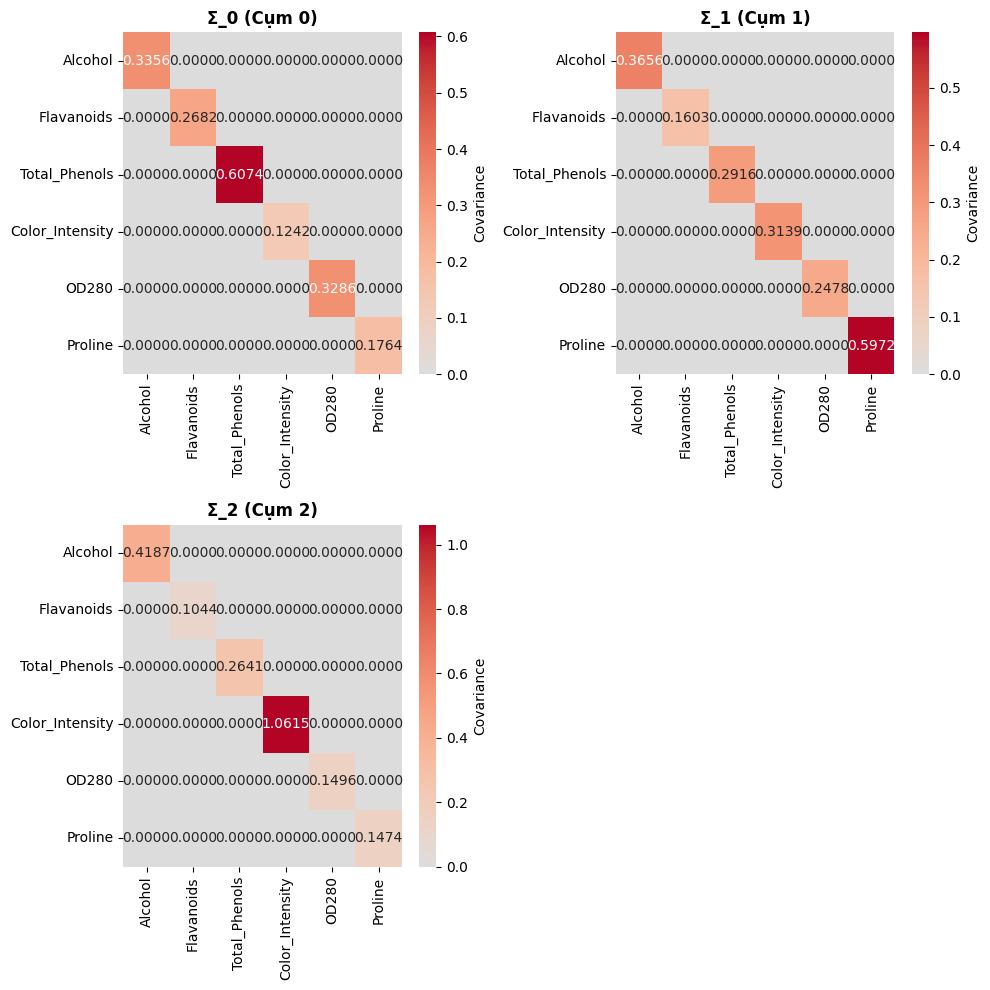


7. LƯU THAM SỐ RA FILE

✓ Đã lưu JSON: gmm_optimal_parameters.json
✓ Đã lưu text chi tiết: gmm_parameters_detailed.txt
✓ Đã lưu Excel: gmm_parameters.xlsx

✅ HOÀN THÀNH - ĐÃ GHI RA TẤT CẢ THAM SỐ

📁 Các file đã tạo:
  1. gmm_optimal_parameters.json       - Tham số dạng JSON
  2. gmm_parameters_detailed.txt       - Tham số chi tiết dạng text
  3. gmm_parameters.xlsx               - Tham số dạng Excel (nhiều sheets)
  4. covariance_matrices_heatmap.png   - Visualize ma trận hiệp phương sai

📋 TÓM TẮT THAM SỐ:
  • Tổng số tham số: 28
  • P_k:  2 tham số
  • μ_k:  18 tham số (3 vectors × 6 chiều)
  • Σ_k:  8 tham số (3 scales + 6 diagonal elements)


In [31]:
"""
GHI RA CHI TIẾT TẤT CẢ THAM SỐ MÔ HÌNH TỐI ƯU
"""
print("=" * 100)
print(" " * 30 + "THAM SỐ MÔ HÌNH GMM TỐI ƯU")
print("=" * 100)

# ============================================================
# THÔNG TIN MÔ HÌNH
# ============================================================
print("\n" + "🏆" * 50)
print("THÔNG TIN MÔ HÌNH")
print("🏆" * 50)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  MÔ HÌNH GAUSSIAN MIXTURE (GMM) TỐI ƯU                                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

📌 Số cụm (K):                 {optimal_K}
📌 Cấu trúc Covariance:         {optimal_cov_type}
📌 Số chiều dữ liệu (p):        {p}
📌 Số mẫu (N):                  {N}
📌 BIC:                         {results_df.iloc[0]['BIC']:.4f}
📌 Log-Likelihood:              {results_df.iloc[0]['Log_Likelihood']:.4f}
📌 Số tham số tổng cộng:        {results_df.iloc[0]['N_Params']}

""")

feature_names = df_2.columns.tolist()
print(f"📊 Features ({p} chiều):")
for i, fname in enumerate(feature_names, 1):
    print(f"    {i}. {fname}")

# ============================================================
# 1. XÁC SUẤT TIÊN NGHIỆM P_k (MIXING PROPORTIONS)
# ============================================================
print("\n" + "=" * 100)
print("1. XÁC SUẤT TIÊN NGHIỆM - P_k (MIXING PROPORTIONS)")
print("=" * 100)

print("\n📊 P_k đại diện cho xác suất một điểm thuộc cụm k:")
print("    • Tổng P_k = 1")
print("    • Số tham số: K - 1 = {} (vì ràng buộc tổng = 1)".format(optimal_K - 1))

pk_df = pd.DataFrame({
    'Cụm k': range(optimal_K),
    'P_k': optimal_P,
    'Phần trăm (%)': optimal_P * 100,
    'Số điểm dự kiến': (optimal_P * N).astype(int),
    'Số điểm thực tế': [np.sum(cluster_labels == k) for k in range(optimal_K)]
})

print("\n" + pk_df.to_string(index=False))
print(f"\n✓ Tổng P_k = {np.sum(optimal_P):.6f} (phải = 1.0)")

# ============================================================
# 2. VECTOR TRUNG BÌNH μ_k (MEAN VECTORS)
# ============================================================
print("\n" + "=" * 100)
print("2. VECTOR TRUNG BÌNH - μ_k (MEAN VECTORS)")
print("=" * 100)

print("\n📊 μ_k là tâm của cụm k trong không gian p-chiều:")
print(f"    • Mỗi cụm có 1 vector μ_k có {p} thành phần")
print(f"    • Số tham số: K × p = {optimal_K} × {p} = {optimal_K * p}")

print("\n" + "─" * 100)
for k in range(optimal_K):
    print(f"\n🎯 CỤM {k} - Vector trung bình μ_{k}:")
    print("─" * 100)
    
    mu_df = pd.DataFrame({
        'Feature': feature_names,
        'μ_k': optimal_mu[k],
        'Giá trị gốc (trước chuẩn hóa)': [
            optimal_mu[k][i] * df_2[fname].std() + df_2[fname].mean() 
            if optimal_cov_type in ['spherical_equal', 'spherical_varying'] 
            else optimal_mu[k][i]
            for i, fname in enumerate(feature_names)
        ]
    })
    print(mu_df.to_string(index=False))

# Bảng tổng hợp tất cả μ_k
print("\n" + "─" * 100)
print("📋 BẢNG TỔNG HỢP TẤT CẢ VECTOR TRUNG BÌNH:")
print("─" * 100)
mu_summary = pd.DataFrame(optimal_mu.T, 
                          index=feature_names,
                          columns=[f'μ_{k} (Cụm {k})' for k in range(optimal_K)])
print(mu_summary.to_string())

# ============================================================
# 3. MA TRẬN HIỆP PHƯƠNG SAI Σ_k (COVARIANCE MATRICES)
# ============================================================
print("\n" + "=" * 100)
print("3. MA TRẬN HIỆP PHƯƠNG SAI - Σ_k (COVARIANCE MATRICES)")
print("=" * 100)

print(f"\n📊 Cấu trúc: {optimal_cov_type}")

if optimal_cov_type == 'spherical_equal':
    print("\n🔹 CẤU TRÚC: Σ_k = η²I (Spherical, Equal)")
    print("    • Tất cả cụm có cùng variance η²")
    print("    • Ma trận đơn vị nhân với scalar η²")
    print(f"    • Số tham số: 1 (chỉ có η²)")
    
    variance = optimal_sigma[0][0, 0]
    print(f"\n✓ η² (variance chung) = {variance:.8f}")
    print(f"\n📐 Ma trận Σ_k = {variance:.6f} × I_{p}x{p}:")
    print(f"    • Ma trận {p}×{p} đường chéo")
    print(f"    • Các phần tử đường chéo = {variance:.6f}")
    print(f"    • Các phần tử ngoài đường chéo = 0")
    
    print("\n🔢 Ma trận Σ (áp dụng cho TẤT CẢ cụm):")
    sigma_df = pd.DataFrame(optimal_sigma[0], 
                           index=feature_names,
                           columns=feature_names)
    print(sigma_df.to_string())

elif optimal_cov_type == 'spherical_varying':
    print("\n🔹 CẤU TRÚC: Σ_k = η_k²I (Spherical, Varying)")
    print("    • Mỗi cụm có variance η_k² riêng")
    print("    • Ma trận đơn vị nhân với scalar khác nhau")
    print(f"    • Số tham số: K = {optimal_K} (mỗi cụm 1 η_k²)")
    
    print("\n✓ Variances cho từng cụm:")
    for k in range(optimal_K):
        variance_k = optimal_sigma[k][0, 0]
        print(f"    • η_{k}² (Cụm {k}) = {variance_k:.8f}")
    
    for k in range(optimal_K):
        print(f"\n🔢 Ma trận Σ_{k} (Cụm {k}):")
        sigma_df = pd.DataFrame(optimal_sigma[k],
                               index=feature_names,
                               columns=feature_names)
        print(sigma_df.to_string())
        print(f"    → Hình dạng: Hình cầu với bán kính √η_{k}² = {np.sqrt(optimal_sigma[k][0,0]):.4f}")

elif optimal_cov_type == 'diagonal':
    print("\n🔹 CẤU TRÚC: Σ_k = η_k²Diag(λ₁,...,λₚ) (Diagonal)")
    print("    • Ma trận chéo với scale khác nhau cho mỗi chiều")
    print("    • Không có correlation giữa các features")
    print(f"    • Số tham số: K×(p+1) + p - 1 = {optimal_K * (p + 2) + p - 1}")
    
    print("\n✓ Diagonal elements (variances) cho từng cụm:")
    diagonal_summary = []
    for k in range(optimal_K):
        diag_vals = np.diag(optimal_sigma[k])
        row = {'Cụm': k}
        for i, fname in enumerate(feature_names):
            row[fname] = diag_vals[i]
        diagonal_summary.append(row)
    
    diag_df = pd.DataFrame(diagonal_summary)
    print(diag_df.to_string(index=False))
    
    for k in range(optimal_K):
        print(f"\n🔢 Ma trận Σ_{k} (Cụm {k}):")
        sigma_df = pd.DataFrame(optimal_sigma[k],
                               index=feature_names,
                               columns=feature_names)
        print(sigma_df.to_string())
        
        # Standard deviations
        std_devs = np.sqrt(np.diag(optimal_sigma[k]))
        print(f"\n    📊 Standard deviations (√diagonal):")
        for i, fname in enumerate(feature_names):
            print(f"        • σ_{k}[{fname}] = {std_devs[i]:.4f}")
        print(f"    → Hình dạng: Ellipsoid với trục song song với các trục tọa độ")

else:  # full
    print("\n🔹 CẤU TRÚC: Σ_k = Full (Unrestricted)")
    print("    • Ma trận hiệp phương sai đầy đủ")
    print("    • Có cả variance và covariance")
    print(f"    • Số tham số mỗi ma trận: p(p+1)/2 = {p * (p + 1) // 2}")
    print(f"    • Tổng số tham số: K × p(p+1)/2 = {optimal_K * p * (p + 1) // 2}")
    
    for k in range(optimal_K):
        print(f"\n{'═' * 100}")
        print(f"🔢 MA TRẬN Σ_{k} ĐẦY ĐỦ (Cụm {k}):")
        print(f"{'═' * 100}")
        
        sigma_df = pd.DataFrame(optimal_sigma[k],
                               index=feature_names,
                               columns=feature_names)
        print("\n" + sigma_df.to_string())
        
        # Eigenvalues và eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(optimal_sigma[k])
        eigenvalues = np.real(eigenvalues)
        
        print(f"\n    📊 PHÂN TÍCH EIGENVALUES (Hình dạng ellipsoid):")
        print(f"    {'─' * 90}")
        eigen_df = pd.DataFrame({
            'Eigenvalue': eigenvalues,
            'Std Dev (√λ)': np.sqrt(eigenvalues),
            '% Variance': eigenvalues / eigenvalues.sum() * 100
        })
        print(eigen_df.to_string(index=False))
        
        print(f"\n    📊 CORRELATION MATRIX (Chuẩn hóa từ covariance):")
        std = np.sqrt(np.diag(optimal_sigma[k]))
        corr_matrix = optimal_sigma[k] / np.outer(std, std)
        corr_df = pd.DataFrame(corr_matrix,
                              index=feature_names,
                              columns=feature_names)
        print(corr_df.to_string())
        
        # Determinant
        det = np.linalg.det(optimal_sigma[k])
        print(f"\n    📊 Determinant |Σ_{k}| = {det:.6e}")
        print(f"    → Thể tích ellipsoid ∝ √|Σ_{k}| = {np.sqrt(det):.6e}")
        print(f"    → Hình dạng: Ellipsoid với trục xoay tùy ý")

# ============================================================
# 4. TỔNG HỢP SỐ THAM SỐ
# ============================================================
print("\n" + "=" * 100)
print("4. TỔNG HỢP SỐ THAM SỐ MÔ HÌNH")
print("=" * 100)

# Tính chi tiết số tham số
if optimal_cov_type == 'spherical_equal':
    n_P = optimal_K - 1
    n_mu = optimal_K * p
    n_sigma = 1
    sigma_desc = "1 variance η² chung"
elif optimal_cov_type == 'spherical_varying':
    n_P = optimal_K - 1
    n_mu = optimal_K * p
    n_sigma = optimal_K
    sigma_desc = f"{optimal_K} variances (η_k² cho mỗi cụm)"
elif optimal_cov_type == 'diagonal':
    n_P = optimal_K - 1
    n_mu = optimal_K * p
    n_sigma = optimal_K + p - 1
    sigma_desc = f"{optimal_K} scales + {p} diagonal elements"
else:  # full
    n_P = optimal_K - 1
    n_mu = optimal_K * p
    n_sigma = optimal_K * p * (p + 1) // 2
    sigma_desc = f"{optimal_K} ma trận {p}×{p} symmetric"

total_params = n_P + n_mu + n_sigma

param_summary = pd.DataFrame({
    'Loại tham số': [
        'P_k (Mixing proportions)',
        'μ_k (Mean vectors)',
        'Σ_k (Covariance matrices)',
        'TỔNG CỘNG'
    ],
    'Số lượng': [n_P, n_mu, n_sigma, total_params],
    'Công thức': [
        f'K - 1 = {optimal_K} - 1',
        f'K × p = {optimal_K} × {p}',
        sigma_desc,
        f'{n_P} + {n_mu} + {n_sigma}'
    ],
    'Chi tiết': [
        f'{n_P} giá trị (phải tổng = 1)',
        f'{optimal_K} vectors, mỗi vector {p} chiều',
        sigma_desc,
        f'{total_params} tham số độc lập'
    ]
})

print("\n" + param_summary.to_string(index=False))

# ============================================================
# 5. HÌNH DẠNG CỦA CÁC CỤM
# ============================================================
print("\n" + "=" * 100)
print("5. HÌNH DẠNG VÀ ĐẶC ĐIỂM CỦA CÁC CỤM")
print("=" * 100)

for k in range(optimal_K):
    print(f"\n{'─' * 100}")
    print(f"CỤM {k}:")
    print(f"{'─' * 100}")
    print(f"  • Xác suất P_{k} = {optimal_P[k]:.4f} ({optimal_P[k]*100:.1f}%)")
    print(f"  • Tâm cụm μ_{k} = {optimal_mu[k]}")
    
    if optimal_cov_type == 'spherical_equal':
        variance = optimal_sigma[k][0, 0]
        print(f"  • Hình dạng: HÌnh CẦU (Sphere)")
        print(f"  • Bán kính: {np.sqrt(variance):.4f}")
        print(f"  • Thể tích tỷ lệ: {variance**(p/2):.4e}")
        
    elif optimal_cov_type == 'spherical_varying':
        variance = optimal_sigma[k][0, 0]
        print(f"  • Hình dạng: HÌNH CẦU (Sphere)")
        print(f"  • Bán kính riêng: {np.sqrt(variance):.4f}")
        print(f"  • Thể tích tỷ lệ: {variance**(p/2):.4e}")
        
    elif optimal_cov_type == 'diagonal':
        diag = np.diag(optimal_sigma[k])
        print(f"  • Hình dạng: ELLIPSOID (trục song song với tọa độ)")
        print(f"  • Độ dài trục:")
        for i, fname in enumerate(feature_names):
            print(f"      - {fname}: {np.sqrt(diag[i]):.4f}")
        print(f"  • Thể tích tỷ lệ: {np.sqrt(np.prod(diag)):.4e}")
        
    else:  # full
        eigenvalues = np.linalg.eigvals(optimal_sigma[k])
        eigenvalues = np.real(eigenvalues)
        print(f"  • Hình dạng: ELLIPSOID (trục xoay tùy ý)")
        print(f"  • Độ dài trục chính (√eigenvalues):")
        for i, ev in enumerate(sorted(eigenvalues, reverse=True)):
            print(f"      - Trục {i+1}: {np.sqrt(ev):.4f}")
        print(f"  • Thể tích tỷ lệ: {np.sqrt(np.prod(eigenvalues)):.4e}")
        print(f"  • Độ lệch chuẩn trung bình: {np.mean(np.sqrt(eigenvalues)):.4f}")

# ============================================================
# 6. VISUALIZE MA TRẬN HIỆP PHƯƠNG SAI
# ============================================================
print("\n" + "=" * 100)
print("6. TRỰC QUAN HÓA MA TRẬN HIỆP PHƯƠNG SAI")
print("=" * 100)

fig, axes = plt.subplots(2, (optimal_K + 1) // 2, figsize=(5 * ((optimal_K + 1) // 2), 10))
if optimal_K == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for k in range(optimal_K):
    ax = axes[k]
    
    # Vẽ heatmap của covariance matrix
    sns.heatmap(optimal_sigma[k], annot=True, fmt='.4f', 
                xticklabels=feature_names, yticklabels=feature_names,
                cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Covariance'})
    ax.set_title(f'Σ_{k} (Cụm {k})', fontsize=12, fontweight='bold')

# Ẩn axes thừa
for k in range(optimal_K, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.savefig('covariance_matrices_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Đã lưu heatmap: covariance_matrices_heatmap.png")
plt.show()

# ============================================================
# 7. LƯU TẤT CẢ THAM SỐ RA FILE
# ============================================================
print("\n" + "=" * 100)
print("7. LƯU THAM SỐ RA FILE")
print("=" * 100)

# Tạo dictionary chứa tất cả tham số
model_params = {
    'model_info': {
        'K': optimal_K,
        'p': p,
        'N': N,
        'covariance_type': optimal_cov_type,
        'BIC': float(results_df.iloc[0]['BIC']),
        'log_likelihood': float(results_df.iloc[0]['Log_Likelihood']),
        'total_parameters': total_params
    },
    'mixing_proportions': {
        f'P_{k}': float(optimal_P[k]) for k in range(optimal_K)
    },
    'mean_vectors': {
        f'mu_{k}': optimal_mu[k].tolist() for k in range(optimal_K)
    },
    'covariance_matrices': {
        f'Sigma_{k}': optimal_sigma[k].tolist() for k in range(optimal_K)
    }
}

# Lưu dưới dạng JSON
import json
with open('gmm_optimal_parameters.json', 'w') as f:
    json.dump(model_params, f, indent=4)
print("\n✓ Đã lưu JSON: gmm_optimal_parameters.json")

# Lưu tham số dạng text chi tiết
with open('gmm_parameters_detailed.txt', 'w', encoding='utf-8') as f:
    f.write("="*100 + "\n")
    f.write("THAM SỐ MÔ HÌNH GMM TỐI ƯU\n")
    f.write("="*100 + "\n\n")
    
    f.write(f"Số cụm K: {optimal_K}\n")
    f.write(f"Cấu trúc Covariance: {optimal_cov_type}\n")
    f.write(f"Số chiều p: {p}\n")
    f.write(f"Số mẫu N: {N}\n")
    f.write(f"BIC: {results_df.iloc[0]['BIC']:.4f}\n")
    f.write(f"Tổng số tham số: {total_params}\n\n")
    
    f.write("\n" + "="*100 + "\n")
    f.write("1. MIXING PROPORTIONS (P_k)\n")
    f.write("="*100 + "\n")
    for k in range(optimal_K):
        f.write(f"P_{k} = {optimal_P[k]:.8f}\n")
    
    f.write("\n" + "="*100 + "\n")
    f.write("2. MEAN VECTORS (μ_k)\n")
    f.write("="*100 + "\n")
    for k in range(optimal_K):
        f.write(f"\nμ_{k}:\n")
        for i, fname in enumerate(feature_names):
            f.write(f"  {fname}: {optimal_mu[k][i]:.8f}\n")
    
    f.write("\n" + "="*100 + "\n")
    f.write("3. COVARIANCE MATRICES (Σ_k)\n")
    f.write("="*100 + "\n")
    for k in range(optimal_K):
        f.write(f"\nΣ_{k}:\n")
        for i in range(p):
            f.write("  [")
            for j in range(p):
                f.write(f"{optimal_sigma[k][i,j]:10.6f} ")
            f.write("]\n")

print("✓ Đã lưu text chi tiết: gmm_parameters_detailed.txt")

# Lưu Excel với nhiều sheets
with pd.ExcelWriter('gmm_parameters.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Model Info
    pd.DataFrame([model_params['model_info']]).T.to_excel(
        writer, sheet_name='Model_Info', header=['Value']
    )
    
    # Sheet 2: Mixing Proportions
    pk_df.to_excel(writer, sheet_name='Mixing_Proportions', index=False)
    
    # Sheet 3: Mean Vectors
    mu_summary.to_excel(writer, sheet_name='Mean_Vectors')
    
    # Sheet 4-N: Covariance matrices
    for k in range(optimal_K):
        sigma_df = pd.DataFrame(optimal_sigma[k],
                               index=feature_names,
                               columns=feature_names)
        sigma_df.to_excel(writer, sheet_name=f'Sigma_{k}')

print("✓ Đã lưu Excel: gmm_parameters.xlsx")

print("\n" + "=" * 100)
print("✅ HOÀN THÀNH - ĐÃ GHI RA TẤT CẢ THAM SỐ")
print("=" * 100)

print("\n📁 Các file đã tạo:")
print("  1. gmm_optimal_parameters.json       - Tham số dạng JSON")
print("  2. gmm_parameters_detailed.txt       - Tham số chi tiết dạng text")
print("  3. gmm_parameters.xlsx               - Tham số dạng Excel (nhiều sheets)")
print("  4. covariance_matrices_heatmap.png   - Visualize ma trận hiệp phương sai")

print("\n" + "="*100)
print("📋 TÓM TẮT THAM SỐ:")
print("="*100)
print(f"  • Tổng số tham số: {total_params}")
print(f"  • P_k:  {n_P} tham số")
print(f"  • μ_k:  {n_mu} tham số ({optimal_K} vectors × {p} chiều)")
print(f"  • Σ_k:  {n_sigma} tham số ({sigma_desc})")
print("="*100)


In [ ]:
# ============================================================
# INITIALIZATION + MULTIPLE RESTARTS (K-MEANS++)
# ============================================================
print("\n" + "=" * 80)
print("INITIALIZATION + MULTIPLE RESTARTS (K-MEANS++)")
print("=" * 80)

from sklearn.cluster import KMeans

def init_kmeans(X, K, n_init=10, random_state=0):
    """
    Khởi tạo tham số GMM bằng K-Means++
    
    Returns:
        p_k_init: Xác suất tiên nghiệm của các cụm
        mu_init: Trung bình của các cụm
        Sigma_init: Ma trận hiệp phương sai của các cụm
    """
    # kmeans++ init
    km = KMeans(n_clusters=K, n_init=n_init, init='k-means++', random_state=random_state)
    labels = km.fit_predict(X)
    mu_init = km.cluster_centers_
    
    # Tính xác suất tiên nghiệm từ số điểm trong mỗi cụm
    N_k = np.bincount(labels, minlength=K).astype(float)
    p_k_init = N_k / X.shape[0]
    
    # Tính ma trận hiệp phương sai cho mỗi cụm
    Sigma_init = []
    for k in range(K):
        points = X[labels == k]
        if len(points) <= 1:
            # Nếu cụm quá nhỏ, dùng ma trận đơn vị
            Sigma_init.append(np.eye(X.shape[1]) * 1e-3)
        else:
            # Tính covariance và thêm regularization
            S = np.cov(points.T) + 1e-3 * np.eye(X.shape[1])
            Sigma_init.append(S)
    
    return p_k_init, mu_init, Sigma_init

def run_em(X, p_k, mu, Sigma, cov_type='full', tol=1e-6, max_iter=200, verbose=False):
    """
    Chạy thuật toán EM với tham số khởi tạo cho trước
    
    Args:
        X: Dữ liệu (N, p)
        p_k: Xác suất tiên nghiệm khởi tạo (K,)
        mu: Trung bình khởi tạo (K, p)
        Sigma: Ma trận hiệp phương sai khởi tạo [list of (p, p)]
        cov_type: Loại cấu trúc covariance
        tol: Ngưỡng hội tụ
        max_iter: Số vòng lặp tối đa
        verbose: In thông tin quá trình
    
    Returns:
        p_k_est: Xác suất tiên nghiệm ước lượng
        mu_est: Trung bình ước lượng
        Sigma_est: Ma trận hiệp phương sai ước lượng
        ll: Log-likelihood cuối cùng
    """
    N, p = X.shape
    K = len(p_k)
    
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        # ========== E-STEP ==========
        # Sử dụng e_step_logspace để tránh underflow
        gamma, log_L, log_tau = e_step_logspace(X, mu, Sigma, p_k)
        
        if verbose and iteration % 50 == 0:
            print(f"  Iteration {iteration}: Log-likelihood = {log_L:.4f}")
        
        # Kiểm tra hội tụ
        if iteration > 0:
            if log_L < prev_log_L - 1e-6:
                import warnings
                warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
            
            if abs(log_L - prev_log_L) < tol:
                if verbose:
                    print(f"  ✓ Hội tụ tại iteration {iteration}")
                break
        
        prev_log_L = log_L
        
        # ========== M-STEP ==========
        p_k, mu, Sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    return p_k, mu, Sigma, log_L

# ============================================================
# MULTIPLE RESTARTS VỚI K-MEANS++ INITIALIZATION
# ============================================================
print("\n📊 Sử dụng mô hình tối ưu từ grid search:")
print(f"  • K = {optimal_K}")
print(f"  • Cấu trúc covariance: {optimal_cov_type}")

# Số lần restart
n_restarts = 10
print(f"\n🔄 Chạy {n_restarts} lần restart với K-Means++ initialization...")

best_ll = -np.inf
best_params = None
all_results = []

for seed in range(n_restarts):
    # Khởi tạo bằng K-Means++
    p_k, mu, Sigma = init_kmeans(X, optimal_K, n_init=1, random_state=seed)
    
    # Chạy EM với khởi tạo này
    p_k_est, mu_est, Sigma_est, ll = run_em(
        X, p_k, mu, Sigma, 
        cov_type=optimal_cov_type, 
        tol=1e-6, 
        max_iter=200, 
        verbose=False
    )
    
    all_results.append({
        'seed': seed,
        'log_likelihood': ll,
        'params': (p_k_est, mu_est, Sigma_est)
    })
    
    print(f"  Restart {seed+1}/{n_restarts}: Log-likelihood = {ll:.4f}")
    
    # Lưu kết quả tốt nhất
    if ll > best_ll:
        best_ll = ll
        best_params = (p_k_est, mu_est, Sigma_est, ll)
        best_seed = seed

# ============================================================
# RELABELLING THEO XÁC SUẤT TIÊN NGHIỆM
# ============================================================

def relabel_by_prior(p_k, mu, Sigma):
    """
    Sắp xếp lại labels theo xác suất tiên nghiệm giảm dần
    
    Args:
        p_k: Xác suất tiên nghiệm (K,)
        mu: Trung bình (K, p)
        Sigma: Ma trận hiệp phương sai [list of (p, p)]
    
    Returns:
        p_k_sorted, mu_sorted, Sigma_sorted
    """
    idx = np.argsort(p_k)[::-1]  # sắp xếp giảm dần
    return p_k[idx], mu[idx], [Sigma[i] for i in idx]

# ============================================================
# KẾT QUẢ TỐI ƯU
# ============================================================
print("\n" + "=" * 80)
print("KẾT QUẢ TỐI ƯU SAU MULTIPLE RESTARTS")
print("=" * 80)

best_p_k, best_mu, best_Sigma, best_ll = best_params

# Relabelling
best_p_k, best_mu, best_Sigma = relabel_by_prior(best_p_k, best_mu, best_Sigma)

print(f"\n🏆 Kết quả tốt nhất:")
print(f"  • Seed: {best_seed}")
print(f"  • Log-likelihood: {best_ll:.6f}")
print(f"\n✓ Xác suất tiên nghiệm (P_k) - đã sắp xếp giảm dần:")
for k in range(optimal_K):
    print(f"  Cụm {k}: {best_p_k[k]:.4f}")

print(f"\n✓ Trung bình các cụm (μ_k):")
for k in range(optimal_K):
    print(f"  Cụm {k}: {best_mu[k]}")

# Gán nhãn cho dữ liệu dựa trên mô hình tốt nhất
best_gamma, _, _ = e_step_logspace(X, best_mu, best_Sigma, best_p_k)
best_labels = np.argmax(best_gamma, axis=1)

print(f"\n✓ Phân bố điểm trong các cụm:")
for k in range(optimal_K):
    count = np.sum(best_labels == k)
    print(f"  Cụm {k}: {count} điểm ({count/N*100:.1f}%)")

# ============================================================
# TRỰC QUAN HÓA SO SÁNH CÁC RESTARTS
# ============================================================
print("\n" + "=" * 80)
print("TRỰC QUAN HÓA")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Log-likelihood của các restarts
ax = axes[0]
seeds = [r['seed'] for r in all_results]
lls = [r['log_likelihood'] for r in all_results]
colors = ['red' if i == best_seed else 'blue' for i in seeds]
bars = ax.bar(seeds, lls, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=best_ll, color='red', linestyle='--', linewidth=2, label=f'Best: {best_ll:.2f}')

# Thêm label cho best seed
for i, (seed, ll) in enumerate(zip(seeds, lls)):
    if seed == best_seed:
        ax.text(seed, ll, f'  Best\n  Seed {seed}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='red')

ax.set_xlabel('Restart (Seed)', fontsize=12, fontweight='bold')
ax.set_ylabel('Log-likelihood', fontsize=12, fontweight='bold')
ax.set_title('Log-likelihood qua các lần Restart', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Phân cụm với mô hình tốt nhất (PCA 2D)
ax = axes[1]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

for k in range(optimal_K):
    mask = best_labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Cụm {k} ({np.sum(mask)} điểm, p={best_p_k[k]:.3f})', 
               alpha=0.6, s=50)

# Vẽ tâm các cụm
mu_pca = pca.transform(best_mu)
ax.scatter(mu_pca[:, 0], mu_pca[:, 1], 
           c='red', marker='X', s=300, 
           edgecolors='black', linewidth=2,
           label='Tâm cụm', zorder=5)

# Thêm label cho các tâm
for k in range(optimal_K):
    ax.text(mu_pca[k, 0], mu_pca[k, 1], f'  {k}', 
            fontsize=12, fontweight='bold', color='red')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title(f'Phân cụm tối ưu (K={optimal_K}, {optimal_cov_type})', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gmm_kmeans_init_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Đã lưu biểu đồ: gmm_kmeans_init_results.png")
plt.show()

# ============================================================
# SO SÁNH VỚI GRID SEARCH
# ============================================================
print("\n" + "=" * 80)